In [7]:
# Goal of this file: plot the convergence process and MCMC results.
# By: Ligang Sun.
# Date: 10/15.

In [1]:
import os
import sys
import numpy as np
from pathlib import Path
import time
import pickle
import uuid

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import corner
import matplotlib.ticker as mticker
import pickle, corner, matplotlib.pyplot as plt

In [2]:
dir_source=Path().resolve()
dir_ref=dir_source/"Reference"
dir_model = dir_source/"Model_results" 
    
def GenColor(N):
    cmap = plt.get_cmap('tab20')  # has 20 distinct colors
    colorarray = ['blue']
    for i in range(1, N):
        color = cmap(i)
        colorarray.append(mcolors.to_hex(color))
    return colorarray
colorarray=GenColor(20)
colorarray[0:5]=['blue','orange','black','green','red','purple']

In [3]:
qxpeakarray=np.arange(0,7,1)
qxpeakarray=qxpeakarray[qxpeakarray != 0]

intmearef=np.load(dir_ref/"intmearef.npy")
inttrueref=np.load(dir_ref/"inttrueref.npy")
intunctyref=np.load(dir_ref/"intunctyref.npy")

rltverrarray=[]
for i in range(len(qxpeakarray)):
    array1=inttrueref[:,i]
    array2=intmearef[:,i]
    rltverr=np.linalg.norm(array1-array2)/np.linalg.norm(array1)
    rltverrarray.append(rltverr)
    print(f"relative error of the {qxpeakarray[i]}th peak, {rltverr:.4f}")

# Overall relative error.
rltverrinit2=np.mean(rltverrarray)
print("Average relative error : ",rltverrinit2)

relative error of the 1th peak, 0.0122
relative error of the 2th peak, 0.0058
relative error of the 3th peak, 0.0060
relative error of the 4th peak, 0.0078
relative error of the 5th peak, 0.0111
relative error of the 6th peak, 0.0118
Average relative error :  0.00912744173717279


In [4]:
# Part 1: convergence analysis.
itnrmax=30 # number of iterations.
itnrarray = np.array(range(1, itnrmax+1))
nrpeaks=len(qxpeakarray)

rltverrfixarray1=rltverrinit2*np.ones_like(itnrarray)

rltverrarray2=[]
datamat=[]
foldername=dir_model/"converge_rltverr_report"
for i in range(1,itnrmax+1):
    filename = os.path.join(foldername, f'rltverr_run_{i}.txt')
    data=np.loadtxt(filename)
    datamat.append(data)
    
    rltverrall2=np.mean(data)
    rltverrarray2.append(rltverrall2)
    
rltverrarray2=np.array(rltverrarray2)
datamat=np.array(datamat)

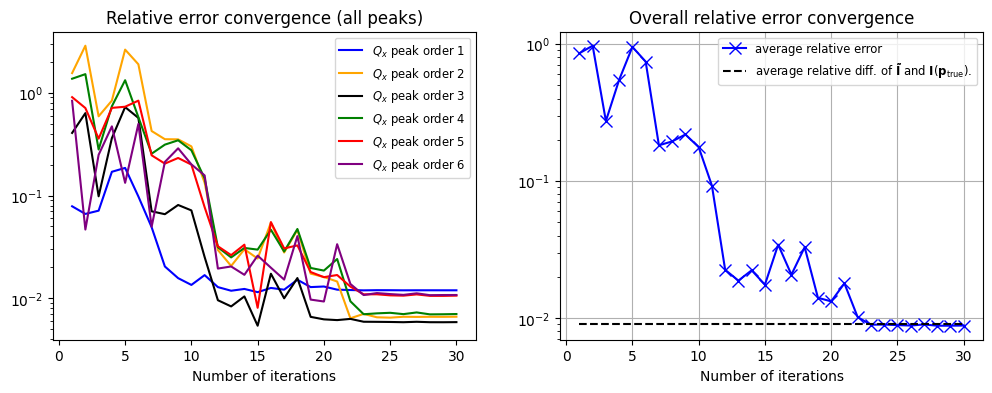

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
for i in range(nrpeaks):
    plt.plot(itnrarray, datamat[:,i], color=colorarray[i], label=rf'$Q_x$ peak order {i+1}')

plt.xlabel('Number of iterations')
plt.ylabel('')
plt.yscale('log')
plt.title('Relative error convergence (all peaks)')
plt.legend(loc='upper right', fontsize='small')

plt.subplot(1,2,2)
plt.plot(itnrarray, rltverrarray2,'-x', color='blue', markersize=8, label='average relative error')
plt.plot(itnrarray, rltverrfixarray1,'--', color='black', markersize=8, 
         label=r'average relative diff. of $\mathbf{\tilde{I}}$ and $\mathbf{I}(\mathbf{p}_{\mathrm{true}})$.')
plt.xlabel('Number of iterations')
plt.ylabel('')
plt.yscale('log')
plt.title('Overall relative error convergence')
plt.legend(loc='upper right', fontsize='small')
plt.grid()

plt.savefig("convergence.png")
plt.show()

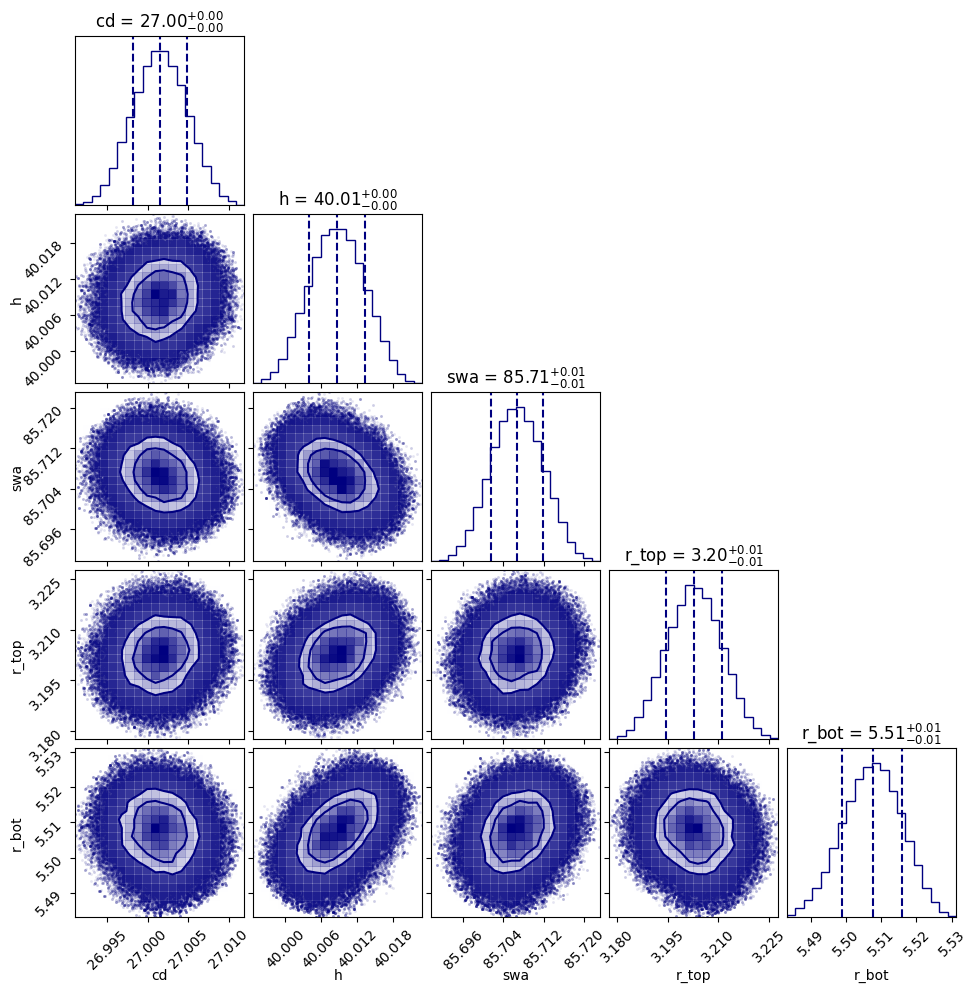

In [9]:
mcmcfile=dir_model/"mcmc_result.pkl"
with open(mcmcfile, "rb") as f:
    mcmc_result = pickle.load(f)

best_sample={'cd': 27.00326510806992, 'h': 40.00137440776898, 'swa': 85.7108092996835, 
               'r_top': 3.195326252813342, 'r_bot': 5.501000659770772}
design_space=[{'name': 'cd'}, {'name': 'h'}, {'name': 'swa'}, {'name': 'r_top'}, {'name': 'r_bot'}]

fig = corner.corner(
    np.array(mcmc_result['samples']),
    quantiles=(0.16, 0.5, 0.84),
    levels=(1 - np.exp(-1.0), 1 - np.exp(-0.5)),
    show_titles=True,
    scale_hist=False,
    title_fmt=".2f",
    labels=[d['name'] for d in design_space],
    color="navy",       # deep blue
    fig=plt.figure(figsize=(10,10))
)

plt.savefig("mcmc.png")